# Week 9 — Decision Trees and Ensembles

This notebook evaluates a CART Decision Tree implemented from scratch in MiniLearn.  
The MiniLearn CART model is the main required model for Week 9.

Scikit-learn Decision Tree, Random Forest, and AdaBoost are used only for empirical comparison, as required by the project roadmap./


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from minilearn.classifiers.decision_tree import _DecisionTree as MiniDecisionTree
from minilearn.metrics.classification_metrics import accuracy, f1_score, confusion_matrix

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score as sk_f1_score,
    classification_report,
    confusion_matrix as sk_confusion_matrix,
    ConfusionMatrixDisplay
)

## Baseline from Previous Weeks

The best previous baseline was Logistic Regression with macro F1 = 0.6236.  
Decision Trees are tested because they learn feature thresholds instead of linear or distance-based boundaries.

In [17]:
baseline_lr_f1 = 0.6236
baseline_svm_f1 = 0.7359

In [18]:
## 1. MiniLearn CART Decision Tree

In [44]:
X_train_sc = np.load('../outputs/X_train_sc.npy')
X_test_sc  = np.load('../outputs/X_test_sc.npy')
y_train    = np.load('../outputs/y_train.npy')
y_test     = np.load('../outputs/y_test.npy')
feat_cols  = pd.read_csv('../outputs/feature_names.csv').iloc[:, 0].tolist()

In [20]:
mini_tree = MiniDecisionTree(
    max_depth=8,
    min_samples_split=5
)

mini_tree.fit(X_train_sc, y_train)
y_pred_mini = mini_tree.predict(X_test_sc)

mini_acc = accuracy(y_test, y_pred_mini)
mini_f1 = f1_score(y_test, y_pred_mini, average="macro")

print(f"MiniLearn CART Accuracy: {mini_acc:.4f}")
print(f"MiniLearn CART Macro F1: {mini_f1:.4f}")

MiniLearn CART Accuracy: 0.3831
MiniLearn CART Macro F1: 0.3762


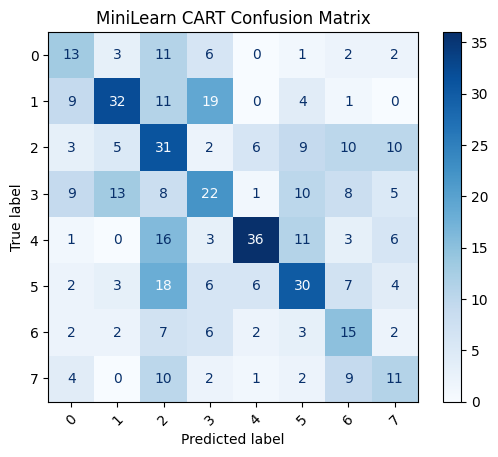

In [21]:
cm = sk_confusion_matrix(y_test, y_pred_mini)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("MiniLearn CART Confusion Matrix")
plt.show()

In [24]:
## 2. MiniLearn Tree Depth Tuning

In [23]:
depth_results = []

for depth in [2, 3, 4, 5, 6, 8, 10, 12, None]:
    model = MiniDecisionTree(
        max_depth=depth,
        min_samples_split=5
    )

    model.fit(X_train_sc, y_train)
    pred = model.predict(X_test_sc)

    depth_results.append({
        "max_depth": depth,
        "accuracy": accuracy(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro")
    })

depth_df = pd.DataFrame(depth_results)
depth_df

,max_depth,accuracy,macro_f1
0,2.0,0.276210,0.183378
1,3.0,0.318548,0.227728
2,4.0,0.346774,0.288827
3,5.0,0.372984,0.348953
4,6.0,0.364919,0.343198
5,8.0,0.375000,0.365643
6,10.0,0.405242,0.384837
7,12.0,0.366935,0.348338
8,NaN,0.383065,0.368042


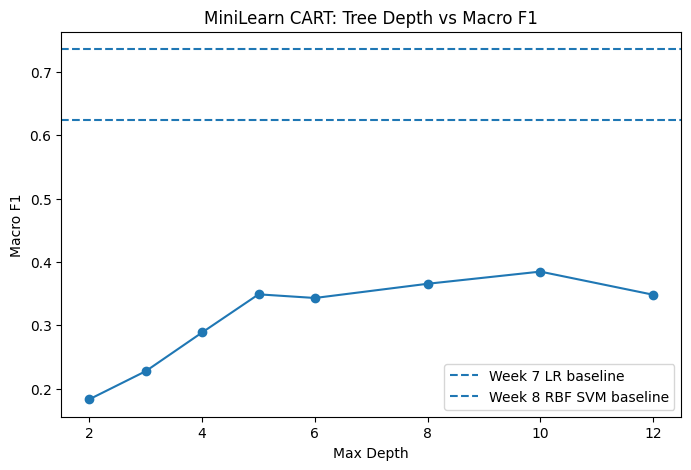

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(depth_df["max_depth"], depth_df["macro_f1"], marker="o")

plt.axhline(baseline_lr_f1, linestyle="--", label="Week 7 LR baseline")
plt.axhline(baseline_svm_f1, linestyle="--", label="Week 8 RBF SVM baseline")

plt.xlabel("Max Depth")
plt.ylabel("Macro F1")
plt.title("MiniLearn CART: Tree Depth vs Macro F1")

plt.legend()
plt.show()

In [27]:
## 3. scikit-learn Decision Tree Comparison

In [28]:
sk_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

sk_tree.fit(X_train_sc, y_train)
y_pred_sk_tree = sk_tree.predict(X_test_sc)

sk_tree_acc = accuracy_score(y_test, y_pred_sk_tree)
sk_tree_f1 = sk_f1_score(y_test, y_pred_sk_tree, average="macro")

print(f"sklearn Decision Tree Accuracy: {sk_tree_acc:.4f}")
print(f"sklearn Decision Tree Macro F1: {sk_tree_f1:.4f}")
print()
print(classification_report(y_test, y_pred_sk_tree))

sklearn Decision Tree Accuracy: 0.3952
sklearn Decision Tree Macro F1: 0.3865

              precision    recall  f1-score   support

           1       0.29      0.32      0.30        38
           2       0.52      0.46      0.49        76
           3       0.29      0.43      0.35        76
           4       0.33      0.29      0.31        76
           5       0.70      0.53      0.60        76
           6       0.43      0.36      0.39        76
           7       0.28      0.38      0.32        39
           8       0.35      0.31      0.33        39

    accuracy                           0.40       496
   macro avg       0.40      0.38      0.39       496
weighted avg       0.42      0.40      0.40       496



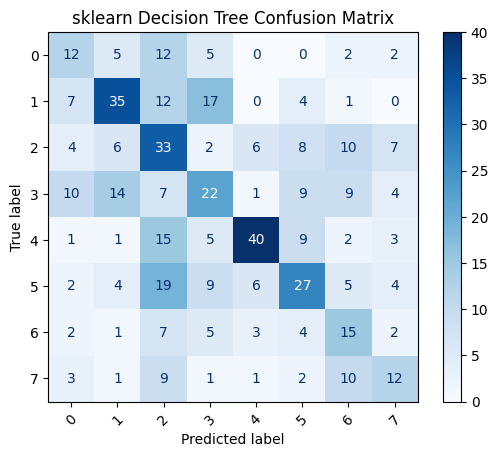

In [29]:
cm = sk_confusion_matrix(y_test, y_pred_sk_tree)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("sklearn Decision Tree Confusion Matrix")
plt.show()

In [30]:
## 4. Random Forest

In [31]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = sk_f1_score(y_test, y_pred_rf, average="macro")

print(f"Random Forest Accuracy: {rf_acc:.4f}")
print(f"Random Forest Macro F1: {rf_f1:.4f}")
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.5665
Random Forest Macro F1: 0.5464

              precision    recall  f1-score   support

           1       0.78      0.37      0.50        38
           2       0.57      0.82      0.67        76
           3       0.53      0.58      0.55        76
           4       0.50      0.45      0.47        76
           5       0.76      0.72      0.74        76
           6       0.46      0.51      0.48        76
           7       0.47      0.38      0.42        39
           8       0.60      0.46      0.52        39

    accuracy                           0.57       496
   macro avg       0.58      0.54      0.55       496
weighted avg       0.58      0.57      0.56       496



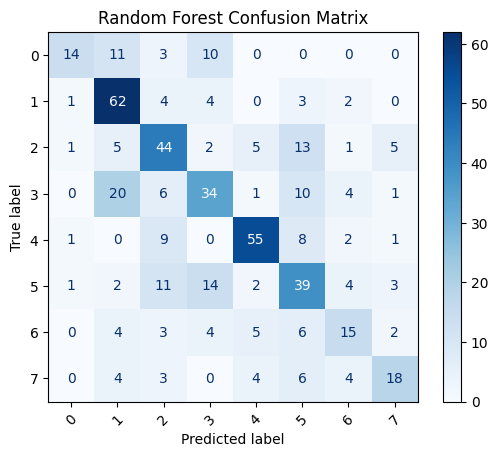

In [32]:
cm = sk_confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [33]:
## 5. AdaBoost

In [34]:
ada = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada.fit(X_train_sc, y_train)
y_pred_ada = ada.predict(X_test_sc)

ada_acc = accuracy_score(y_test, y_pred_ada)
ada_f1 = sk_f1_score(y_test, y_pred_ada, average="macro")

print(f"AdaBoost Accuracy: {ada_acc:.4f}")
print(f"AdaBoost Macro F1: {ada_f1:.4f}")
print()
print(classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.3669
AdaBoost Macro F1: 0.3325

              precision    recall  f1-score   support

           1       0.40      0.05      0.09        38
           2       0.48      0.47      0.48        76
           3       0.37      0.33      0.35        76
           4       0.30      0.39      0.34        76
           5       0.51      0.59      0.55        76
           6       0.24      0.30      0.27        76
           7       0.31      0.28      0.30        39
           8       0.32      0.26      0.29        39

    accuracy                           0.37       496
   macro avg       0.37      0.34      0.33       496
weighted avg       0.37      0.37      0.36       496



In [35]:
## 6. Model Comparison

In [36]:
week9_results = pd.DataFrame([
    {"Source": "MiniLearn", "Model": "MiniLearn CART", "Accuracy": mini_acc, "Macro F1": mini_f1},
    {"Source": "sklearn", "Model": "sklearn Decision Tree", "Accuracy": sk_tree_acc, "Macro F1": sk_tree_f1},
    {"Source": "sklearn", "Model": "Random Forest", "Accuracy": rf_acc, "Macro F1": rf_f1},
    {"Source": "sklearn", "Model": "AdaBoost", "Accuracy": ada_acc, "Macro F1": ada_f1},
    {"Source": "Previous", "Model": "Week 7 Logistic Regression", "Accuracy": np.nan, "Macro F1": baseline_lr_f1},
    {"Source": "Previous", "Model": "Week 8 RBF SVM", "Accuracy": np.nan, "Macro F1": baseline_svm_f1},
])

week9_results

,Source,Model,Accuracy,Macro F1
0,MiniLearn,MiniLearn CART,0.383065,0.376167
1,sklearn,sklearn Decision Tree,0.395161,0.386485
2,sklearn,Random Forest,0.566532,0.546448
3,sklearn,AdaBoost,0.366935,0.332545
4,Previous,Week 7 Logistic Regression,NaN,0.623600
5,Previous,Week 8 RBF SVM,NaN,0.735900


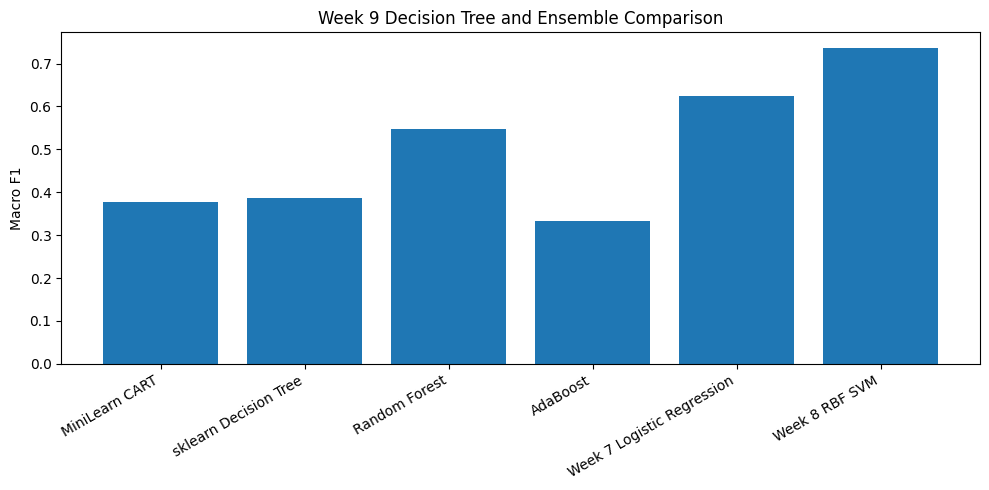

In [37]:
plt.figure(figsize=(10, 5))
plt.bar(week9_results["Model"], week9_results["Macro F1"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Macro F1")
plt.title("Week 9 Decision Tree and Ensemble Comparison")
plt.tight_layout()
plt.show()

In [38]:
## 7. Feature Importance

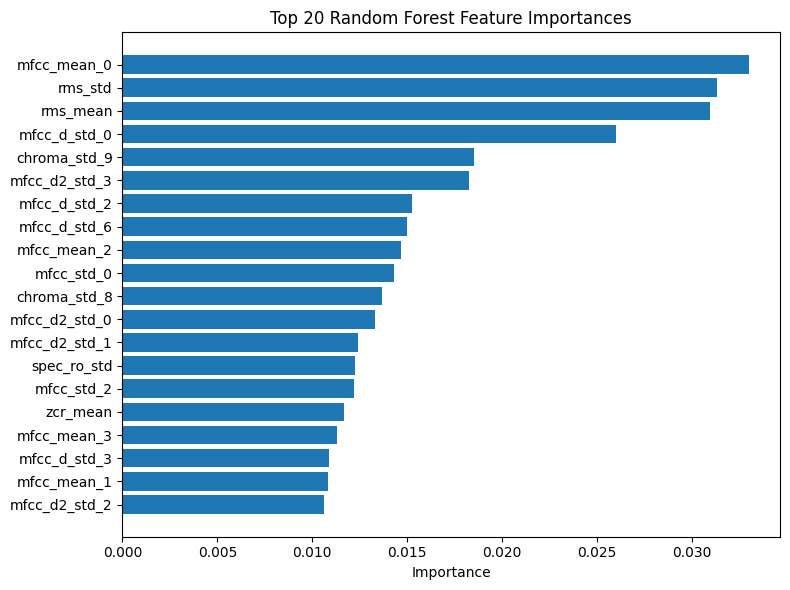

In [46]:
importances = pd.DataFrame({
    "feature": feat_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

top = importances.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top["feature"][::-1], top["importance"][::-1])

plt.xlabel("Importance")
plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [41]:
## 8. Visualizing a Decision Tree

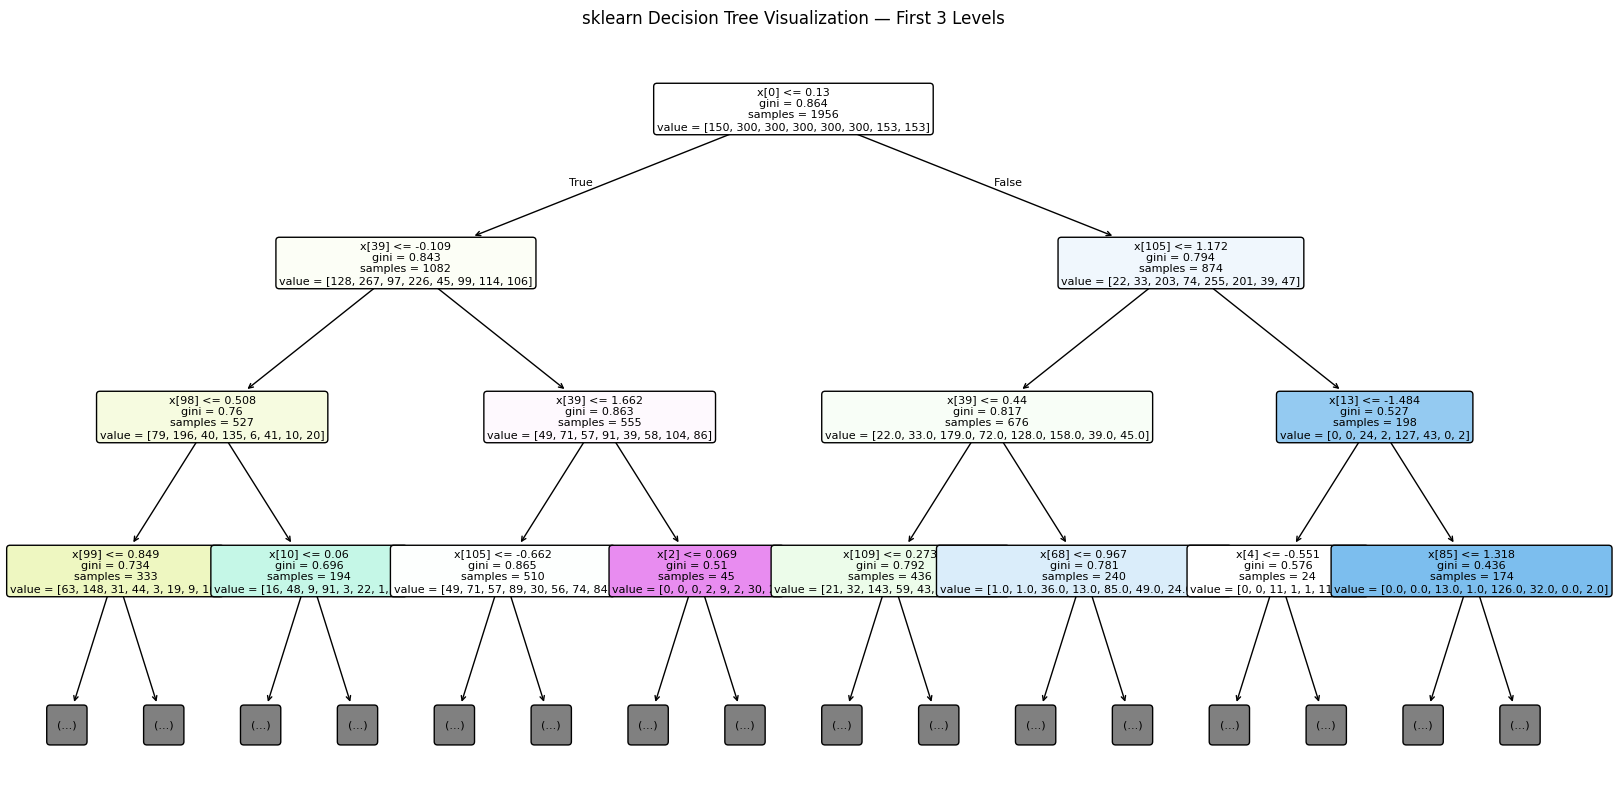

In [49]:
plt.figure(figsize=(20, 10))

plot_tree(
    sk_tree,
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("sklearn Decision Tree Visualization — First 3 Levels")
plt.show()

## Summary

- MiniLearn CART was implemented from scratch and used as the main Week 9 model.

- CART learns decision rules by splitting features at threshold values. This is different from Logistic Regression and SVM, which learn linear or margin-based boundaries.

- A single Decision Tree is interpretable but can overfit if the tree becomes too deep.

- Tree depth tuning showed how increasing depth affects generalization. Shallow trees may underfit, while very deep trees may memorize training patterns.

- Random Forest improved generalization by averaging many decision trees trained on different samples and feature subsets.

- AdaBoost combined many weak learners by focusing more on samples that previous trees misclassified.

- Tree-based models are useful for SER because they can capture non-linear feature interactions between MFCCs, RMS energy, ZCR, and spectral features.

- Compared with SVM, tree models are more interpretable but may require ensembles to achieve strong performance.